# Engineering Neural Networks Portfolio Project

## Setup

In [1]:
!pip install -r requirements.txt

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

  Using cached numpy-2.2.6-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached pandas-2.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached scipy-1.15.3-cp312-cp312-macosx_14_0_arm64.whl.metadata (61 kB)
  Using cached scikit_learn-1.7.2-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached sympy-1.13.3-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached numexpr-2.10.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (1.2 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached matplotlib-3.10.7-cp312-cp312-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached torch-2.4.1-cp312-none-macosx_11_0_arm64.whl.metadata (26 kB)
  Using cached torchvision-0.19.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.0 kB)
ERROR: Ignored the following 

[nltk_data] Downloading package punkt_tab to /Users/Alex/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/Alex/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Project Framework

### 1. Business Understanding: Use AI to automate classification of customer banking queries into predefined intent categories to improve routing, response time, and customer experience.


- Improve first-response accuracy
- Reduce manual triage time for customer support

### 2. Data Understanding: The Banking77 dataset contains labeled customer queries across 77 banking intent classes.

- Inspect class distribution and identify imbalances
- Analyze text lengths across intent classes

### 3. Data Preparation: Clean and preprocess text for modeling.

- Normalize, pad, and/or truncate text
- Tokenization using transformer-compatible tokenizers

### 4. Modeling: Finetuned transformer-based model for contextual understanding and performance.

- Baseline: Multi-Layer Perceptron (MLP)
- Advanced model: Finetuned RoBERTa using LoRA

### 5. Evaluation: Define classification performance metrics.

- Primary metric: Macro F1 Score
- Secondary metrics: Overall accuracy, precision, recall
- Comparison: Baseline vs advanced model performance

### 6. Deployment: Save and load the finetuned LoRA-RoBERTa model.

- AI ethics: Ensure data security and privacy of customer queries by redacting sensitive personally identifiable information (PII)
- Inference pipeline: Customer query -> Redact PII -> Predict banking intent
- Monitor: Track live performance, potential data drift, and collect data for retraining

## Exploratory Data Analysis

In [2]:
# Import the datasets
train = pd.read_csv('/Users/Alex/Documents/Coding/3. AI Engineer Career Path/engineer-neural-networks-portfolio-project/datasets/banking77_train.csv')
test = pd.read_csv('/Users/Alex/Documents/Coding/3. AI Engineer Career Path/engineer-neural-networks-portfolio-project/datasets/banking77_test.csv')

# Print key info
print("Train DataFrame:")
print("\nInfo: \n", train.info())
print("\nNull Values: \n", train.isna().sum())
print("\nInitial Values: \n", train.head())
print("\nShape: \n", train.shape)

print("\nTest DataFrame:")
print("\nInfo: \n", test.info())
print("\nNull Values: \n", test.isna().sum())
print("\nInitial Values: \n", test.head())
print("\nShape: \n", test.shape)

Train DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   text      10003 non-null  str  
 1   category  10003 non-null  str  
dtypes: str(2)
memory usage: 943.8 KB

Info: 
 None

Null Values: 
 text        0
category    0
dtype: int64

Initial Values: 
                                                 text      category
0                     I am still waiting on my card?  card_arrival
1  What can I do if my card still hasn't arrived ...  card_arrival
2  I have been waiting over a week. Is the card s...  card_arrival
3  Can I track my card while it is in the process...  card_arrival
4  How do I know if I will get my card, or if it ...  card_arrival

Shape: 
 (10003, 2)

Test DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 3080 entries, 0 to 3079
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 

<>:12: SyntaxWarning: invalid escape sequence '\T'
<>:12: SyntaxWarning: invalid escape sequence '\T'
/var/folders/57/cryl7wqx1fn9pftrpn26lzwc0000gp/T/ipykernel_40006/26407017.py:12: SyntaxWarning: invalid escape sequence '\T'
  print("\Test Unique Labels: \n", test.value_counts("category"))


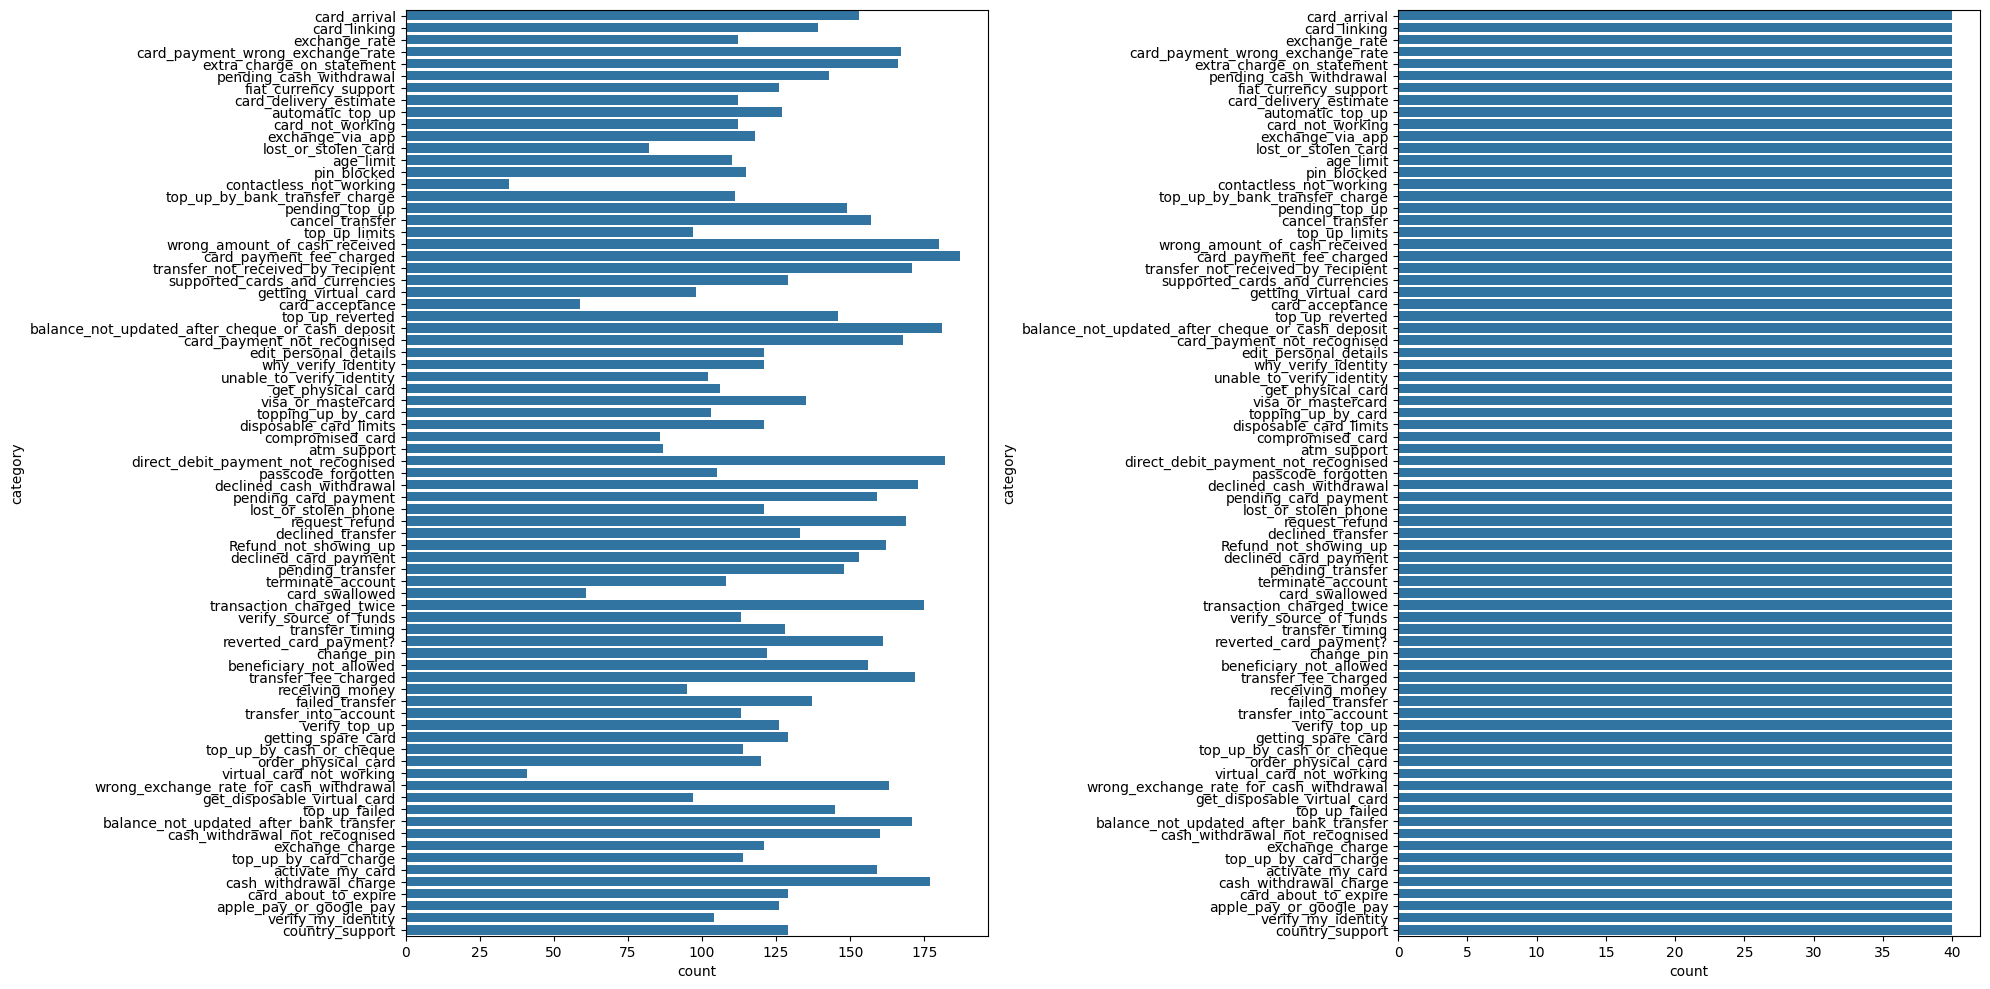


Train Unique Labels: 
 category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
                                                   ... 
lost_or_stolen_card                                  82
card_swallowed                                       61
card_acceptance                                      59
virtual_card_not_working                             41
contactless_not_working                              35
Name: count, Length: 77, dtype: int64
\Test Unique Labels: 
 category
card_arrival                        40
card_linking                        40
exchange_rate                       40
card_payment_wrong_exchange_rate    40
extra_charge_on_statement           40
                                    ..
cash_withdrawal_charge              40
card_abo

In [3]:
# Calculate number of unique labels
train_label_count = train.value_counts("category")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
sns.countplot(data=train, y="category", ax=ax1)
sns.countplot(data=test, y="category", ax=ax2)
plt.tight_layout()
plt.show()

print("\nTrain Unique Labels: \n", train_label_count)
print("\Test Unique Labels: \n", test.value_counts("category"))

In [4]:
# Count top words per category
def count_top_words(df):
    # Initialise top_words dict
    top_words = {}

    # Create series grouped by Category
    grouped = df.groupby('category')['text'].apply(' '.join)

    # Loop over each category to calculate top 5 word occurrences, filtering out stop words
    for category, text in grouped.items():
        filtered = [word for word in text.split() if word not in stop_words]
        top_words[category] = Counter(filtered).most_common(5)

    # Find top words in combined text set
    top_words_combined = Counter(filtered).most_common(20)

    print(f"Top 20 Words in Dataset: {top_words_combined}\n")
    print(f"Top 5 Words per Category (Filtering out Stopwords):\n{top_words}\n")

print("Top Words in Train Dataset:\n")
count_top_words(train)
print("Top Words in Test Dataset:\n")
count_top_words(test)

Top Words in Train Dataset:

Top 20 Words in Dataset: [('I', 180), ('exchange', 109), ('rate', 102), ('cash', 80), ('wrong', 37), ('ATM', 33), ('got', 28), ('The', 25), ('money', 24), ('withdrawal', 23), ('wrong.', 22), ('applied', 21), ('currency', 19), ('get', 19), ('withdraw', 16), ('foreign', 15), ('think', 14), ('holiday', 13), ('Can', 13), ('When', 12)]

Top 5 Words per Category (Filtering out Stopwords):
{'Refund_not_showing_up': [('I', 151), ('refund', 139), ('see', 34), ('money', 26), ('requested', 26)], 'activate_my_card': [('I', 112), ('activate', 86), ('card', 65), ('card?', 47), ('new', 43)], 'age_limit': [('I', 39), ('account', 38), ('open', 37), ('age', 34), ('account?', 32)], 'apple_pay_or_google_pay': [('top', 78), ('I', 74), ('Apple', 43), ('Google', 32), ('Can', 31)], 'atm_support': [('I', 49), ('ATMs', 23), ('card?', 23), ('use', 22), ('Where', 19)], 'automatic_top_up': [('I', 84), ('auto', 61), ('top', 32), ('top-up', 27), ('Can', 25)], 'balance_not_updated_after_b

Train Dataset Response Lengths:

Average length of response in dataset: 11.949415175447365

Average length of response per category: {'Refund_not_showing_up': np.float64(15.808641975308642), 'activate_my_card': np.float64(9.150943396226415), 'age_limit': np.float64(9.236363636363636), 'apple_pay_or_google_pay': np.float64(10.341269841269842), 'atm_support': np.float64(7.689655172413793), 'automatic_top_up': np.float64(9.047244094488189), 'balance_not_updated_after_bank_transfer': np.float64(14.701754385964913), 'balance_not_updated_after_cheque_or_cash_deposit': np.float64(14.237569060773481), 'beneficiary_not_allowed': np.float64(12.307692307692308), 'cancel_transfer': np.float64(13.949044585987261), 'card_about_to_expire': np.float64(11.976744186046512), 'card_acceptance': np.float64(7.47457627118644), 'card_arrival': np.float64(10.431372549019608), 'card_delivery_estimate': np.float64(9.0625), 'card_linking': np.float64(12.517985611510792), 'card_not_working': np.float64(9.848214285

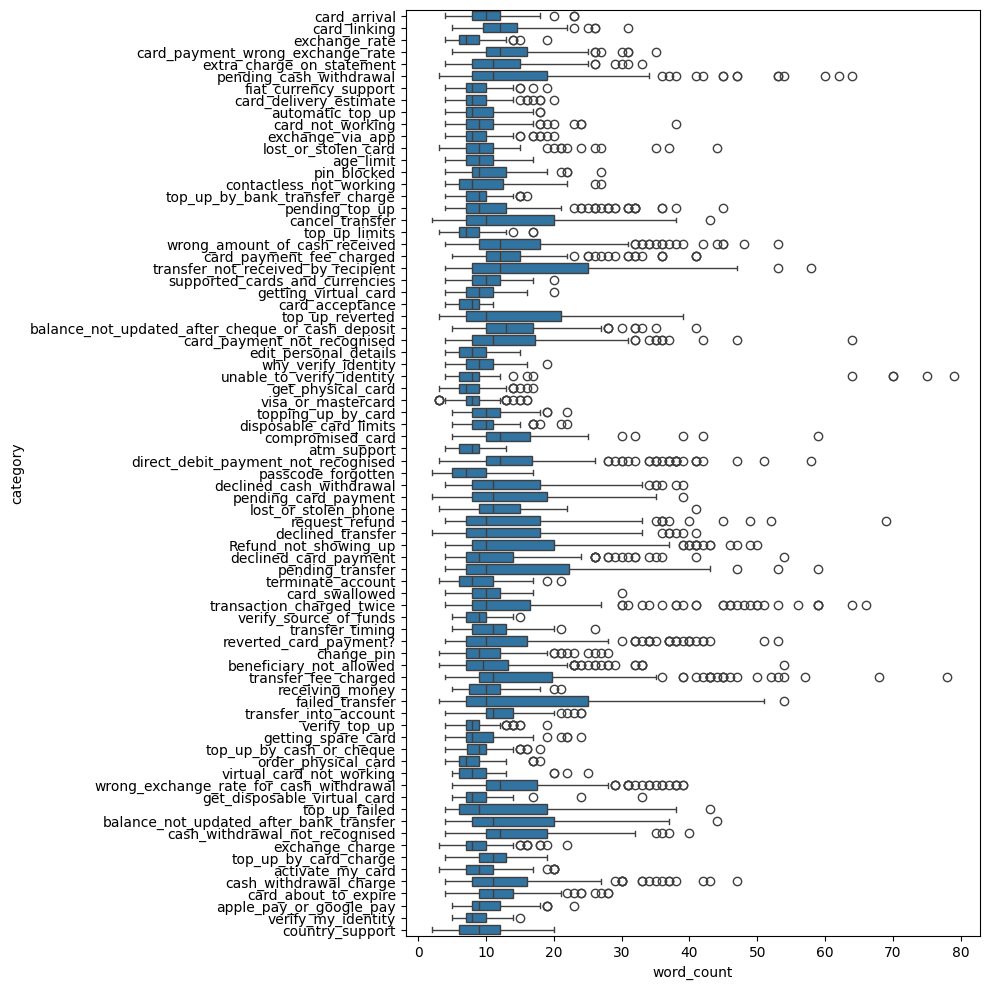

Test Dataset Response Lengths:

Average length of response in dataset: 10.952597402597403

Average length of response per category: {'Refund_not_showing_up': np.float64(15.575), 'activate_my_card': np.float64(9.25), 'age_limit': np.float64(10.0), 'apple_pay_or_google_pay': np.float64(10.475), 'atm_support': np.float64(7.475), 'automatic_top_up': np.float64(10.225), 'balance_not_updated_after_bank_transfer': np.float64(13.35), 'balance_not_updated_after_cheque_or_cash_deposit': np.float64(14.0), 'beneficiary_not_allowed': np.float64(12.425), 'cancel_transfer': np.float64(11.1), 'card_about_to_expire': np.float64(13.45), 'card_acceptance': np.float64(7.375), 'card_arrival': np.float64(10.55), 'card_delivery_estimate': np.float64(8.2), 'card_linking': np.float64(11.275), 'card_not_working': np.float64(7.6), 'card_payment_fee_charged': np.float64(12.65), 'card_payment_not_recognised': np.float64(13.975), 'card_payment_wrong_exchange_rate': np.float64(12.5), 'card_swallowed': np.float64(10.

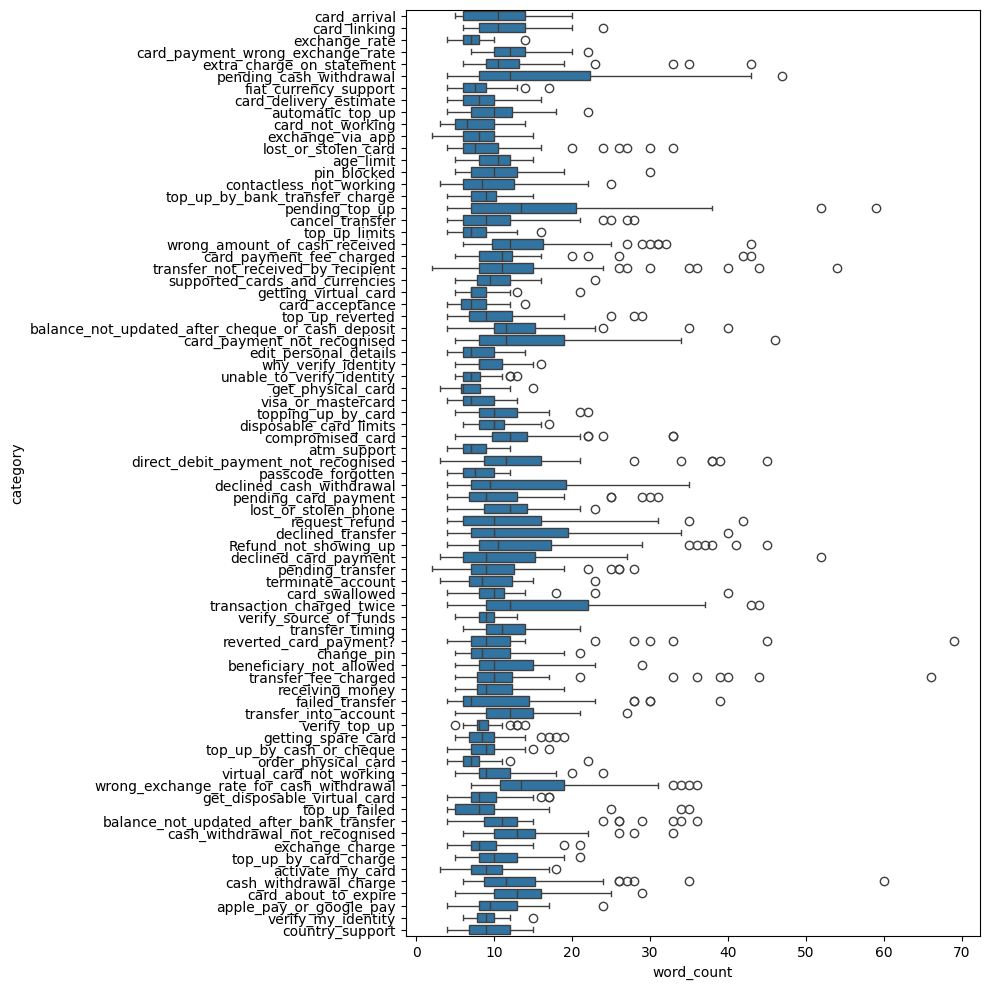

In [5]:
# Calculate average length of response
def response_length(df):
    av_length_combined = df['text'].str.split().str.len().mean()
    
    av_length_category = {}

    df['word_count'] = df['text'].str.split().str.len()

    # Create series grouped by Category
    grouped = df.groupby('category')['text']

    # Loop over each category to calculate average word length of text response
    for category, text in grouped:
        av_length_category[category] = text.str.split().str.len().mean()

    print(f"Average length of response in dataset: {av_length_combined}\n")
    print(f"Average length of response per category: {av_length_category}\n")

    fig, (ax1) = plt.subplots(1, figsize=(10, 10))
    sns.boxplot(data=df, x='word_count', y='category', ax=ax1)
    plt.tight_layout()
    plt.show()

print("Train Dataset Response Lengths:\n")
response_length(train)
print("Test Dataset Response Lengths:\n")
response_length(test)

## Data Preparation for Machine Learning

In [13]:
def load_glove(filepath):
    embeddings = {}
    
    with open(filepath, 'r') as file:
        for line in file:
            parts = line.split()
            word = parts[0]
            vector = [float(x) for x in parts[1:]]

            embeddings[word] = vector
    
    print(f"Loaded {filepath} successfully!")

    return embeddings

embeddings = load_glove('/Users/Alex/Documents/Coding/3. AI Engineer Career Path/engineer-neural-networks-portfolio-project/glove.6B/glove.6B.50d.txt')

def preparation(df):
    '''
    Function that prepares a DataFrame for Machine Learning:
    1. LabelEncoder converts label (Category column) into encoded numbers
    2. Cleans text responses (removal of punctuation, lowercase)

    Args: DataFrame
    '''

    # Convert intents into numbers with LabelEncoder
    le = LabelEncoder()
    df['label'] = le.fit_transform(df['category'])

    # Clean text responses
    df['text'] = df['text'].str.lower().replace('[^\w\s]', '', regex=True)

    # Tokenize text responses
    df['text_tokenized'] = df['text'].apply(word_tokenize)

    # Get embeddings
    def embed_text(tokens, embeddings):
        '''
        Function that finds embeddings for each token.
        Words not in embedding database labelled UNK - unknown.

        Args: token list(s)
        '''

        vectors = []
        for token in tokens:
            vectors.append(embeddings.get(token, [0] * 50))

        return vectors

    df['embedded_text'] = df['text_tokenized'].apply(lambda x: embed_text(x, embeddings))

    def pad_sequence(vectors, max_len=40):
        '''
        Function that:
            - Pads embedding vectors < len(40)
            - Truncates embedding vectors > len(40)

        Args: 
            - List of vectors
            - Maximum length beyond which to truncate
        '''

        if len(vectors) < max_len:
            vectors = vectors + [[0] * 50] * (max_len - len(vectors))
        else:
            vectors = vectors[:max_len]
        return vectors
    
    df['padded_vector'] = df['embedded_text'].apply(pad_sequence)

preparation(train)
print(train.head())

<>:32: SyntaxWarning: invalid escape sequence '\w'
<>:32: SyntaxWarning: invalid escape sequence '\w'
/var/folders/57/cryl7wqx1fn9pftrpn26lzwc0000gp/T/ipykernel_40006/3359591389.py:32: SyntaxWarning: invalid escape sequence '\w'
  df['text'] = df['text'].str.lower().replace('[^\w\s]', '', regex=True)


Loaded /Users/Alex/Documents/Coding/3. AI Engineer Career Path/engineer-neural-networks-portfolio-project/glove.6B/glove.6B.50d.txt successfully!
                                                text      category  \
0                      i am still waiting on my card  card_arrival   
1  what can i do if my card still hasnt arrived a...  card_arrival   
2  i have been waiting over a week is the card st...  card_arrival   
3  can i track my card while it is in the process...  card_arrival   
4  how do i know if i will get my card or if it i...  card_arrival   

   word_count  label                                     text_tokenized  \
0           7     12              [i, am, still, waiting, on, my, card]   
1          13     12  [what, can, i, do, if, my, card, still, hasnt,...   
2          12     12  [i, have, been, waiting, over, a, week, is, th...   
3          13     12  [can, i, track, my, card, while, it, is, in, t...   
4          15     12  [how, do, i, know, if, i, will, get,